# Bayesian linear mixture model

In [8]:
import geopandas as gpd
import numpy as np
from cmdstanpy import CmdStanModel
import os 
import arviz as az
import matplotlib.pyplot as plt

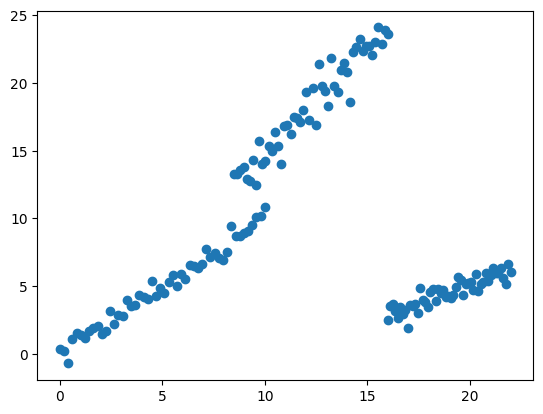

In [9]:
N=3*50

alpha1=0
alpha2=0
alpha3=-5

beta1=1
beta2=1.5
beta3=0.5

sigma1=0.5
sigma2=1
sigma3=0.5

X1=np.linspace(0,10,int(N/3))
X2=np.linspace(8.5,16,int(N/3))
X3=np.linspace(16,22,int(N/3))

Y1=np.zeros(int(N/3))
Y2=np.zeros(int(N/3))
Y3=np.zeros(int(N/3))


for k in range(int(N/3)):
    Y1[k]=np.random.normal(loc=beta1*X1[k]+alpha1, scale=sigma1)
    Y2[k]=np.random.normal(loc=beta2*X2[k]+alpha2, scale=sigma2)
    Y3[k]=np.random.normal(loc=beta3*X3[k]+alpha3, scale=sigma3)


    # X[3*k]=X1[k]
    # X[3*k+1]=X2[k]
    # X[3*k+2]=X3[k]


X=np.concatenate([X1,X2,X3])
Y=np.concatenate([Y1,Y2,Y3])

plt.scatter(X,Y)

X=X.reshape(-1,1)


Stan Model

In [10]:
str_model="""
data {
    // Data
    int N;
    int P;

    int K; //nb of clusters

    matrix[N, P] X;
    array[N] real y;

    
    // Prior parameters
    array[4] real p0_params;
    //real alpha; //in our model alpha=1
}

transformed data {
    real a0 = p0_params[1];
    real b0 = p0_params[2];
    real sigma0 = p0_params[3];
    real sigma1 = p0_params[4];
}

parameters {
    array[K] real alpha;
    matrix[K,P] beta; 
    array[K] real<lower=0> sigma;
    simplex[K] weights;

}

transformed parameters {
    matrix[N,K] mu;
    for(i in 1:N) {
        for(k in 1:K) {

            mu[i,k] = dot_product(row(X, i), beta[k]) + alpha[k];
        }
        
    }
}


model {

    vector[K] contributions;
    for (i in 1:N) {
        for(k in 1:K) {
            contributions[k] = log(weights[k]) + normal_lpdf(y[i] | mu[i,k], sigma[k]);
            // y[i] ~ normal(mu[i], sigma);  

            }
            target += log_sum_exp(contributions);
        }

        
    
    weights ~ dirichlet(rep_vector(1, K));

    for(k in 1:K) {
        alpha[k] ~ normal(0, a0);

        for (j in 1:P) {
            beta[k,j] ~ normal(0, b0);
        }
        
        sigma[k] ~ inv_gamma(sigma0, sigma1);
    }
}

generated quantities {
    array[N] int cluster_allocs;
    for(i in 1:N){
        vector[K] log_probs = log(weights);
        for(k in 1:K) {
            log_probs[k] += normal_lpdf(y[i] | mu[i,k], sigma[k]);
        }
        cluster_allocs[i] = categorical_rng(softmax(log_probs))-1;
    }
}

"""


if not os.path.exists("./stan"):
    os.mkdir("./stan")
stan_file = "./stan/linear_model.stan"
with open(stan_file, "w") as f:
    print(str_model, file=f)

# Compile stan model
linear_model = CmdStanModel(stan_file=stan_file)

14:34:38 - cmdstanpy - INFO - compiling stan file /Users/paul/Documents/Polimi/bayesian_stat/projet/contrib_paul/models/stan/linear_model.stan to exe file /Users/paul/Documents/Polimi/bayesian_stat/projet/contrib_paul/models/stan/linear_model
14:34:54 - cmdstanpy - INFO - compiled model executable: /Users/paul/Documents/Polimi/bayesian_stat/projet/contrib_paul/models/stan/linear_model


In [11]:
K=3
N=len(Y)
P=1
gmm_data = {
    "N": N,
    "P":P,
    "K":K,

    "X":X,
    "y": Y,

    "p0_params": np.array([30, 10, 3, 2]),
    #"alpha":1
}

# Algorithm parameters
algo_params = {
    "n_chains": 4,
    "n_burnin": 1000,
    "n_iter": 1000
}

# Sample
model = linear_model.sample(data=gmm_data, chains=algo_params["n_chains"], parallel_chains=algo_params["n_chains"],
                                  iter_warmup=algo_params["n_burnin"], iter_sampling=algo_params["n_iter"])

# Convert to arviz data type
chains = az.from_cmdstanpy(model)

14:34:54 - cmdstanpy - INFO - CmdStan start processing















































































































































































































































































































































































































chain 1: 100%|██████████| 2000/2000 [00:12<00:00, 158.37it/s, (Sampling completed)]




chain 2: 100%|██████████| 2000/2000 [00:12<00:00, 158.37it/s, (Sampling completed)]





chain 3: 100%|██████████| 2000/2000 [00:12<00:00, 158.36it/s, (Sampling completed)]






chain 4: 100%|██████████| 2000/2000 [00:12<00:00, 158.38it/s, (Sampling completed)]


14:35:07 - cmdstanpy - INFO - CmdStan done processing.
14:35:07 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'linear_model.stan', line 50, column 12 to column 87)
Consider re-running with show_console=True if the above output is unclear!


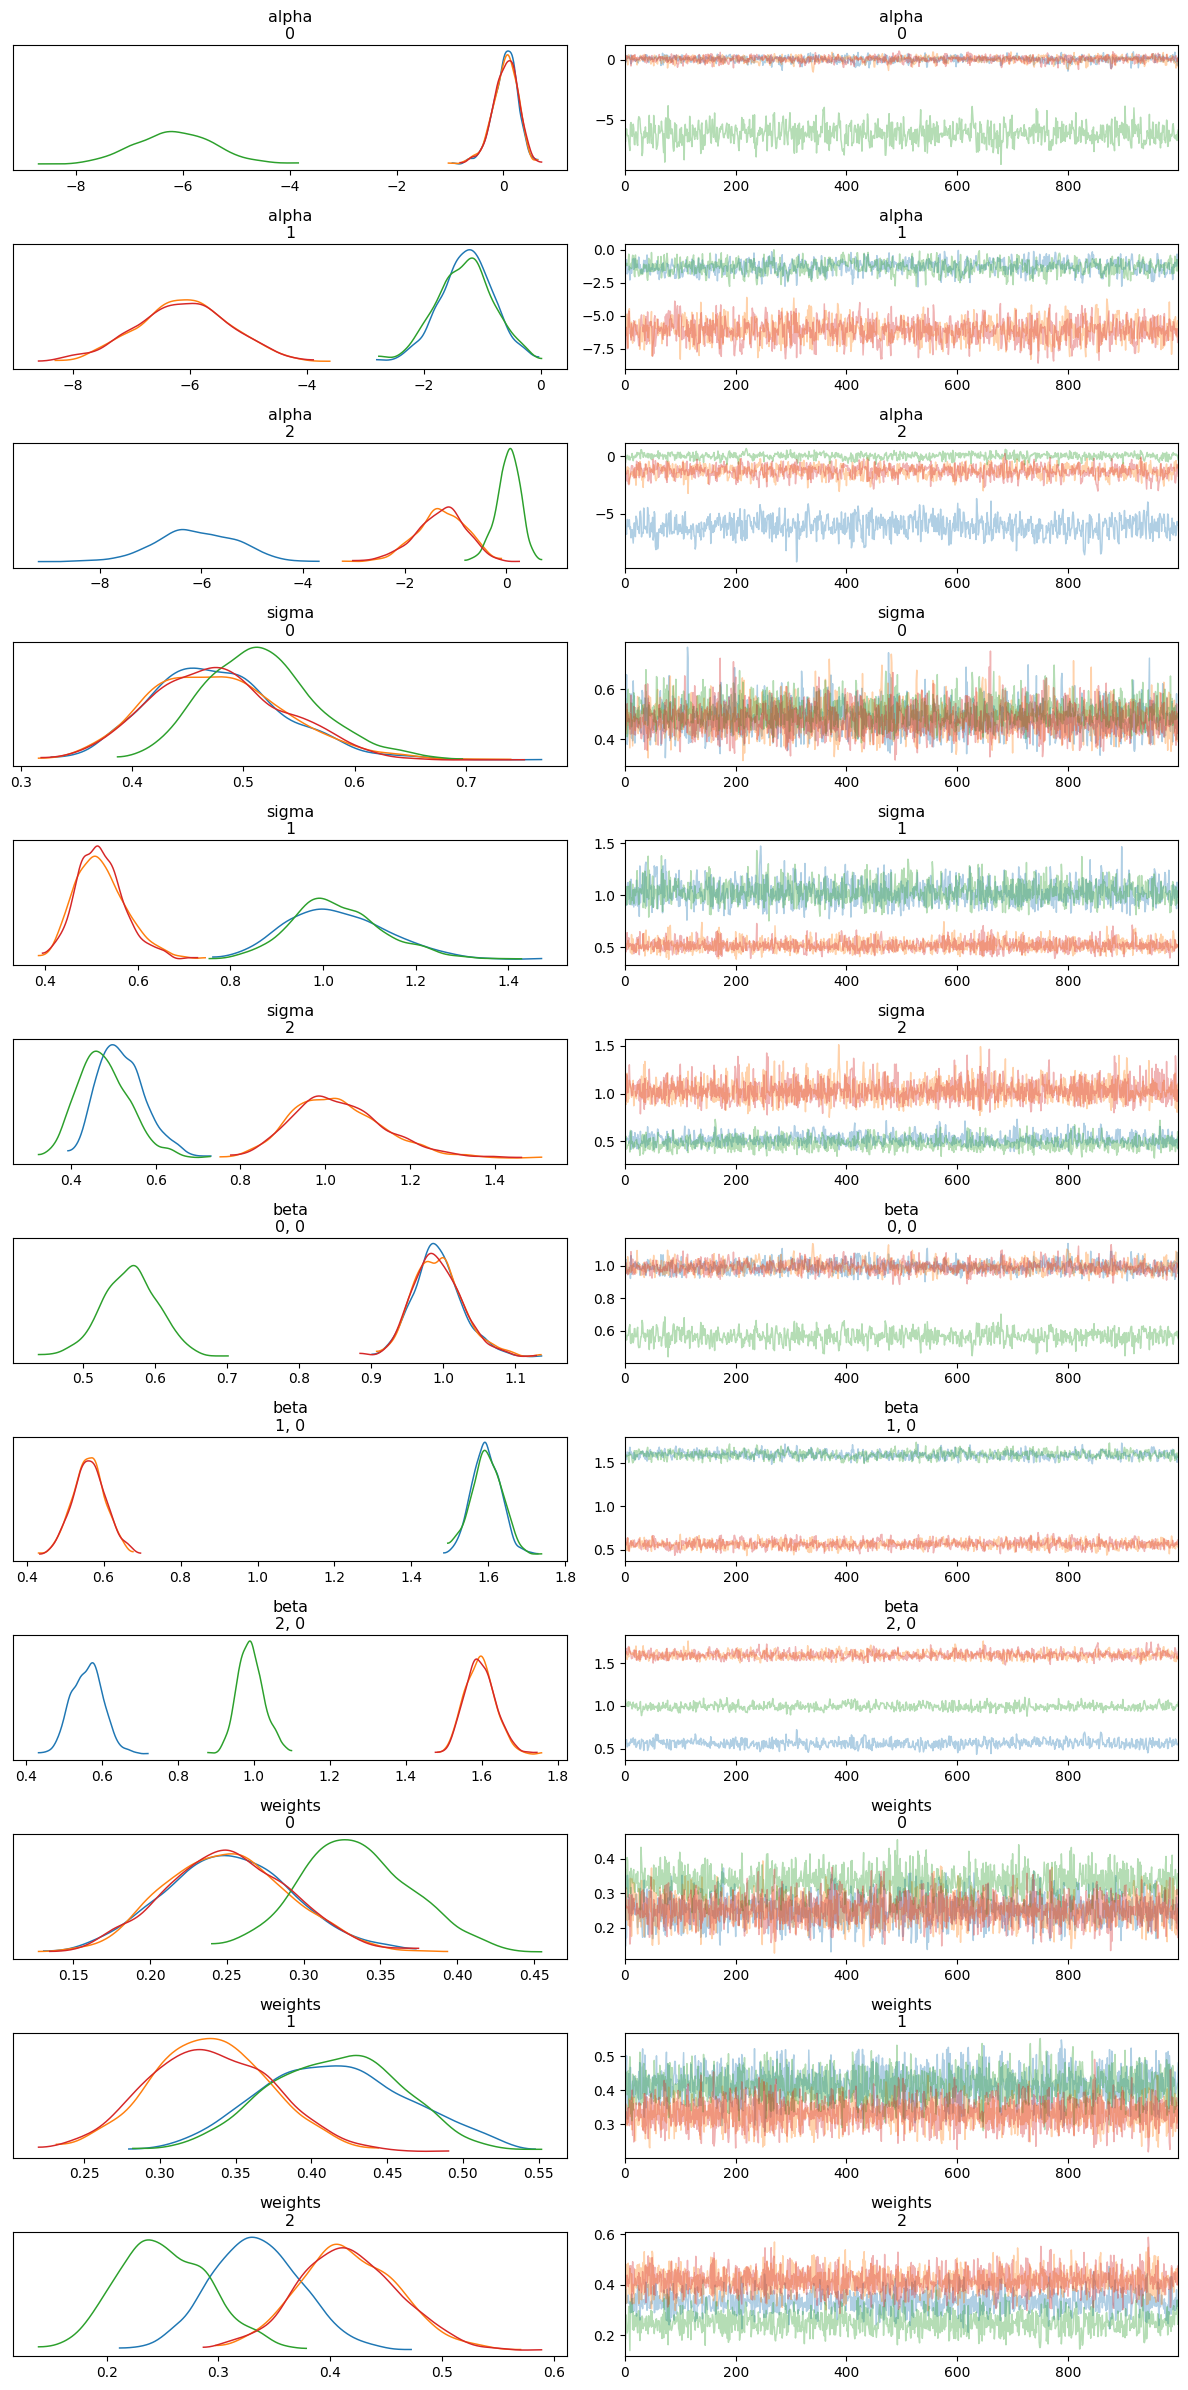

In [12]:
az.plot_trace(chains, var_names=["alpha","sigma", "beta","weights"], compact=False)
plt.tight_layout()
plt.show()

## Visualization of the predictive density given x_i (part not rigorous)

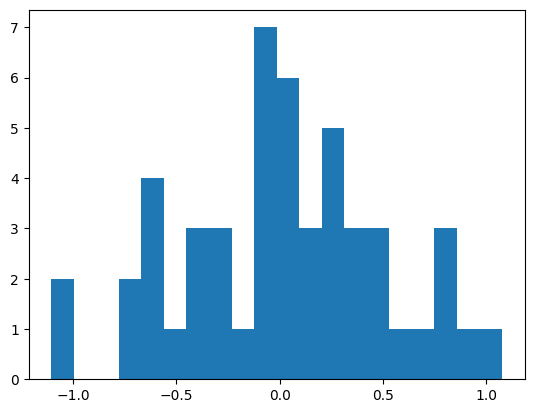

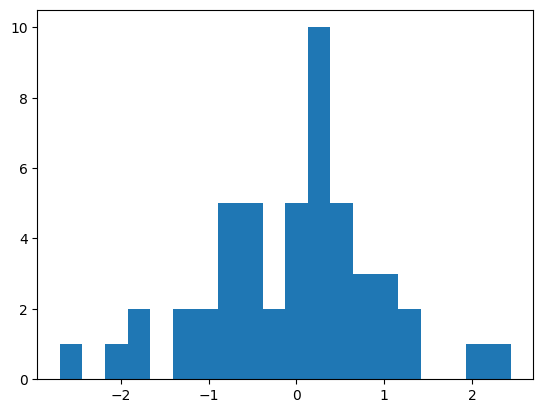

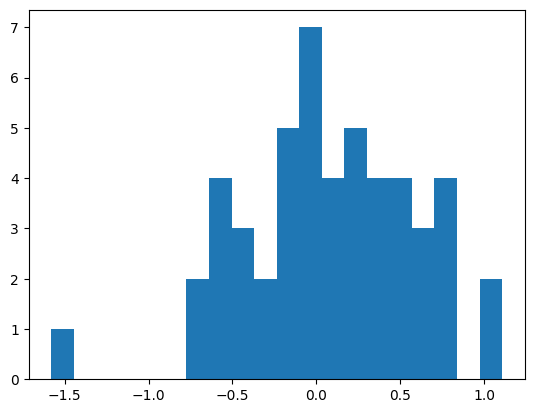

In [13]:
Y1_dis=Y1-(beta1*X1+alpha1)
Y2_dis=Y2-(beta2*X2+alpha2)
Y3_dis=Y3-(beta3*X3+alpha3)

plt.hist(Y1_dis,bins=20)
plt.show()
plt.hist(Y2_dis,bins=20)
plt.show()
plt.hist(Y3_dis,bins=20)
plt.show()

(4, 1000, 3)
(4000, 3)
mu.shape (4000, 150, 3)


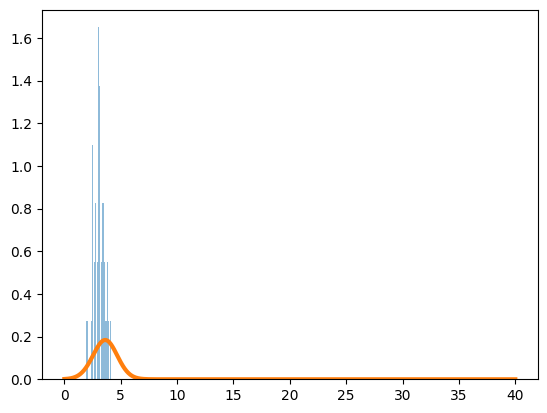

In [14]:
from tensorflow_probability.substrates import numpy as tfp
tfd = tfp.distributions

# def predictive_gaussian_mix_uni(chains, x_grid,ind_instance):
#     # Extract chains
#     weights = np.vstack(chains.posterior.weights)
#     # print(weights.shape)
#     mu = np.vstack(chains.posterior.mu)
#     print("mu.shape",mu.shape)
#     sigma = np.vstack(chains.posterior.sigma)
#     num_components = weights.shape[1]
#     # Create buffer and fill
#     out = np.zeros(shape=(weights.shape[0], len(x_grid)))
#     for j in range(out.shape[0]):
#         eval_dens = np.zeros_like(x_grid)
#         for k in range(num_components):
#             eval_dens += weights[j,k] * tfd.Normal(mu[j,ind_instance,k], sigma[j,k]).prob(x_grid)
#         out[j,:] = eval_dens
#     # Copmute mean
#     return np.mean(out, axis=0)

def predictive_gaussian_mix_uni(chains, x_grid,ind_instance,cluster_k):
    # Extract chains
    print(chains.posterior.weights.shape)
    weights = np.vstack(chains.posterior.weights)
    print(weights.shape)
    mu = np.vstack(chains.posterior.mu)
    print("mu.shape",mu.shape)
    sigma = np.vstack(chains.posterior.sigma)
    num_components = weights.shape[1]
    # Create buffer and fill
    out = np.zeros(shape=(weights.shape[0], len(x_grid)))
    for j in range(out.shape[0]):
        eval_dens = np.zeros_like(x_grid)
        # for k in range(num_components):
        eval_dens += tfd.Normal(mu[j,ind_instance,cluster_k], sigma[j,cluster_k]).prob(x_grid)
        out[j,:] = eval_dens
    # Copmute mean
    return np.mean(out, axis=0)

x = np.linspace(0, 40, 1000)
# x = np.linspace(0, 40, 1000)

# Compute posterior mean density
ind_instance=15
post_dens = predictive_gaussian_mix_uni(chains, x, ind_instance,cluster_k=1)
# Plot posterior mean density

plt.hist(Y1_dis+(beta1*X[ind_instance]+alpha1), density=True, alpha = 0.5, bins = 30)
# plt.hist(Y2_dis+(beta2*X[ind_instance]+alpha2), density=True, alpha = 0.5, bins = 30)
plt.plot(x, post_dens, linewidth=3)

plt.show()


## In this part, we want to assign y_i to a cluster (0,1,2)

In [15]:
# Function that computes the posterior similarity matrix
def get_psm(clus_alloc_chain):
    c_chain = np.vstack(clus_alloc_chain)
    out = np.zeros((c_chain.shape[1], c_chain.shape[1]))
    for i in range(c_chain.shape[1]):
        for j in range(i):
            out[i, j] = np.mean(c_chain[:, i] == c_chain[:, j])
    return out + out.T + np.eye(out.shape[0])



In [16]:
# Function that computes the cluster estimate that minimizes the binder loss function
def minbinder_sample(clus_alloc_chain, psm):
    losses = np.zeros(len(clus_alloc_chain))
    c_chain = np.vstack(clus_alloc_chain)
    for i in range(c_chain.shape[1]):
        for j in range(i):
            losses += (np.mean(c_chain[:, i] == c_chain[:, j]) - psm[i, j]) ** 2
    best_iter = np.argmin(losses)
    return clus_alloc_chain[best_iter]

In [17]:
# Retrieve cluster allocation variables
clust_allocs_chain = np.vstack(chains.posterior.cluster_allocs)

In [18]:
# Compute posterior similarity matrix
psm = get_psm(clust_allocs_chain)

In [19]:
# Compute point estimate of the cluster
best_clus = minbinder_sample(clust_allocs_chain, psm)

## In this part, we want to derive the coefficients alpha and beta for each cluster.

In [20]:
# print(model.summary()[:20])

# alphas_recovered=model.summary().iloc[1:4,0].values
# betas_recovered=model.summary().iloc[4:7,0].values



In [21]:
# from scipy.stats import gaussian_kde

# def posterior_mode(samples, n_grid=2000):
#     kde = gaussian_kde(samples)
#     x = np.linspace(samples.min(), samples.max(), n_grid)
#     return x[np.argmax(kde(x))]



# alpha=np.vstack(chains.posterior.alpha)
# print(alpha.shape)

# alpha_modes = {}
# for i in range(alpha.shape[1]):
#     alpha_modes[f"alpha[{i+1}]"] = posterior_mode(alpha[:, i])

# alpha_modes

In [22]:
# from scipy.optimize import linear_sum_assignment


# aligned_beta = []
# aligned_alpha = []


# beta_chain=np.vstack(chains.posterior.beta)
# alpha_chain=np.vstack(chains.posterior.alpha)
# print(beta_chain.shape)
# print(clust_allocs_chain.shape)

# for t in range(clust_allocs_chain.shape[0]):
#     zt = clust_allocs_chain[t]

#     # cost matrix
#     cost = np.zeros((K,K))
#     for k in range(K):
#         for h in range(K):
#             cost[k,h] = np.sum((zt == k) & (best_clus != h))

#     row_ind, col_ind = linear_sum_assignment(cost)

#     beta_t = beta_chain[t][row_ind]
#     alpha_t = alpha_chain[t][row_ind]

#     aligned_beta.append(beta_t)
#     aligned_alpha.append(alpha_t)


# beta_retrieved=np.mean(aligned_beta, axis=0)[:,0]
# alpha_retrieved=np.mean(aligned_alpha, axis=0)

# print("beta_retrieved",beta_retrieved)

# print("alpha_retrieved",alpha_retrieved)


## Visualization of the results

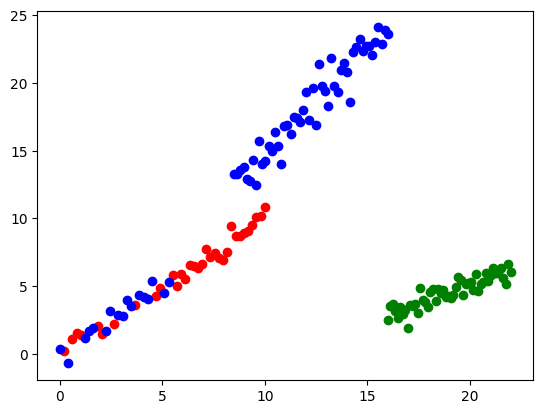

In [23]:
# Plot the point cluster estimate on the empirical density histogram
# plt.hist(data, density=True, alpha=0.3)


color_map = {
    0: "red",      # couleur1
    1: "blue",     # couleur2
    2: "green"     # etc.
}

k=0
for h in np.unique(best_clus):
    currd_Y = Y[best_clus == h]
    currd_X= X[best_clus == h]
    plt.scatter(currd_X,currd_Y,c=color_map[h])
    # plt.plot(currd_X,currd_X*beta_retrieved[k]+alpha_retrieved[k],c=color_map[h])
    k+=1



In [24]:
print("model.summary",model.summary()[:20])


model.summary                   Mean      MCSE    StdDev       MAD          5%         50%  \
lp__       -306.092000  0.064520  2.431650  2.292530 -310.611000 -305.801000   
alpha[1]     -1.512890  1.896140  2.712580  0.360666   -6.801450   -0.048222   
alpha[2]     -3.698590  1.716380  2.503870  3.377620   -7.180470   -3.209310   
alpha[3]     -2.167380  1.661880  2.402850  1.448800   -6.744870   -1.274510   
beta[1,1]     0.885340  0.131261  0.188583  0.050231    0.532590    0.976192   
beta[2,1]     1.078970  0.365023  0.518281  0.763999    0.507364    1.090130   
beta[3,1]     1.186660  0.308613  0.438470  0.473762    0.524056    1.288930   
sigma[1]      0.487999  0.010984  0.062394  0.062235    0.391406    0.484668   
sigma[2]      0.775302  0.182459  0.268859  0.365150    0.456350    0.749627   
sigma[3]      0.765759  0.190492  0.280846  0.382199    0.421813    0.741028   
weights[1]    0.271830  0.026949  0.053872  0.056317    0.190580    0.266587   
weights[2]    0.373995  0.